In [13]:
import pandas as pd

df = pd.read_parquet("https://huggingface.co/datasets/VatsalPatel18/Weather-Chatbot-Dataset/resolve/main/data/train-00000-of-00001.parquet")

#splits = {'train': 'data/train-00000-of-00001.parquet', 'validation': 'data/validation-00000-of-00001.parquet'}
#df = pd.read_parquet("hf://datasets/VatsalPatel18/Weather-Chatbot-Dataset/" + splits["train"])
df

,conversations,text
0,"{'api_response': {'date': '2024-06-16', 'descr...",<s>
1,"{'api_response': None, 'assistant_response': N...",<s>
2,"{'api_response': None, 'assistant_response': N...",<s>
3,"{'api_response': None, 'assistant_response': N...",<s>
4,"{'api_response': None, 'assistant_response': N...",<s>
...,...,...
1155,"{'api_response': None, 'assistant_response': N...",<s>
1156,"{'api_response': {'date': None, 'description':...",<s>
1157,"{'api_response': {'date': None, 'description':...",<s>
1158,"{'api_response': None, 'assistant_response': N...",<s>


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1160 entries, 0 to 1159
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   conversations  1160 non-null   object
 1   text           1160 non-null   object
dtypes: object(2)
memory usage: 18.3+ KB


In [15]:
df.shape

(1160, 2)

In [16]:
df.isna().sum()

conversations    0
text             0
dtype: int64

In [ ]:
# Supprime les lignes uniquement si la colonne 'conversations' est vide
df = df.dropna(subset=['conversations'])

In [17]:
# On extrait la valeur associée à la clé 'user_input' pour chaque ligne
df['user_input'] = df['conversations'].apply(lambda x: x['user_input'])

In [18]:
#Nettoyage : suppression de la ponctuation (exemple simple)
df['user_input_clean'] = df['user_input'].str.replace('[^\w\s]','', regex=True).str.lower()

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_144\1891872884.py:2: SyntaxWarning: invalid escape sequence '\w'
  df['user_input_clean'] = df['user_input'].str.replace('[^\w\s]','', regex=True).str.lower()


In [19]:
df[['user_input', 'user_input_clean']].head()

,user_input,user_input_clean
0,What is the forecast weather in San Diego 2024...,what is the forecast weather in san diego 2024...
1,What is the current weather in Sydney today?,what is the current weather in sydney today
2,What is the current weather in Ankara today?,what is the current weather in ankara today
3,What is the forecast weather in Moscow 2024-06...,what is the forecast weather in moscow 2024061...
4,What is the forecast weather in Stockholm 2024...,what is the forecast weather in stockholm 2024...


In [37]:
df['user_input_clean'].isna().sum()

np.int64(0)

In [20]:
# Supprime les doublons basés uniquement sur la colonne de texte nettoyé
df = df.drop_duplicates(subset=['user_input_clean'])

In [22]:
df.shape

(832, 4)

In [23]:
# Extraction de l'intention (ex: current_weather)
df['intent'] = df['conversations'].apply(lambda x: x['intent_extraction']['intent'] if x['intent_extraction'] else None)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_144\2473442678.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['intent'] = df['conversations'].apply(lambda x: x['intent_extraction']['intent'] if x['intent_extraction'] else None)


In [26]:
# Compter le nombre d'occurrences pour chaque intention
frequence = df['intent'].value_counts()
frequence

intent
forecast_weather    311
current_weather     170
Name: count, dtype: int64

In [38]:
df['intent'].isna().sum()

np.int64(351)

In [48]:
df = df.dropna(subset=['intent'])

In [49]:
df['intent'].isna().sum()

np.int64(0)

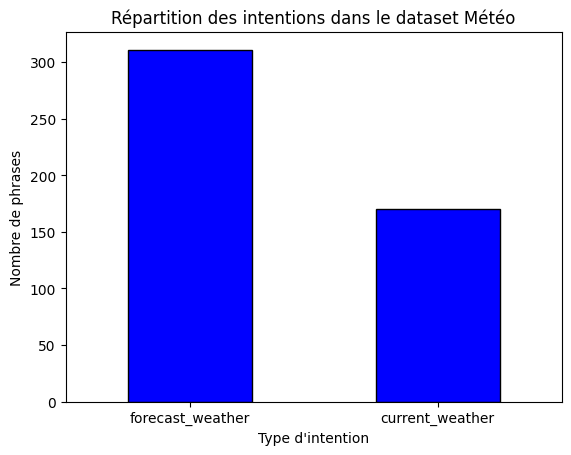

In [34]:
import matplotlib.pyplot as plt

# Créer le graphique à barres
frequence.plot(kind='bar', color='blue', edgecolor='black')

# Ajouter des titres et étiquettes
plt.title("Répartition des intentions dans le dataset Météo")
plt.xlabel("Type d'intention")
plt.ylabel("Nombre de phrases")
plt.xticks(rotation = 0) # Pour mieux lire les noms
plt.show()

# Etape 3 : Choix, entrainement et sauvegarde du modele

In [ ]:
'''from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

# 1. Préparation des X (texte) et y (intentions)
X = df['user_input_clean']
y = df['intent']

# 2. Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Transformation du texte en nombres
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 4. Entraînement d'un classifieur simple (SVM)
model = SVC()
model.fit(X_train_vec, y_train)

# 5. Sauvegarde du modèle et du vectoriseur
joblib.dump(model, 'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')'''

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# 1. Préparation des données (X = texte nettoyé, y = intentions)
# On suppose que vous avez déjà créé 'user_input_clean' et 'intent' à l'étape 2
X = df['user_input_clean']
y = df['intent']

# 2. Division des données en entraînement (80%) et test (20%) [1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Vectorisation TF-IDF (Transformation du texte en nombres pour le modèle)
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 4. Création et entraînement de la Forêt Aléatoire [1, 2]
# On utilise 100 arbres pour commencer
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_tfidf, y_train)

# 5. Évaluation des résultats [2]
y_pred = model_rf.predict(X_test_tfidf)

print(f"Accuracy (Précision globale) : {accuracy_score(y_test, y_pred):.2f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

# Affichage de la Matrice de Confusion [2]
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

# 6. Sauvegarde du modèle et du vectoriseur
joblib.dump(model_rf, 'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

Accuracy (Précision globale) : 1.00

Rapport de classification :
                  precision    recall  f1-score   support

 current_weather       1.00      1.00      1.00        29
forecast_weather       1.00      1.00      1.00        68

        accuracy                           1.00        97
       macro avg       1.00      1.00      1.00        97
    weighted avg       1.00      1.00      1.00        97



['vectorizer.pkl']

# Etape 4 : Deploiement du modele dans le Cloud